# Measurement x=15, y=0, z=0

### TODO
- LR for potentials on whole plane
- LR Improvement comparison on whole y-z space
- Moving to 3D? And u_y?
- Learning on whole y-z plane
- Rigorous ML e.g. with more feature

##### Optional
- Calculate experiment delta_l_y

##### Dmitry Q&A:
- $\mathrm{Ha} = 300$ implies a relation between system properties. How to determine $B$ and $\sigma$ for Ohm's law? According to the data, they must be as I have calculated. Am I right?
- $\sigma = -1$? Where is the error?
- $B = -1$ as well?
- Why is there an error, even if I use $\frac{\partial{\phi}}{\partial{y}}$ from the simulation?

### Imports

In [116]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from python_utils.utils import load_object

from python_utils.time_series_extraction import extract_timeseries
from python_utils.time_series_extraction import find_matching_row_index_from_timeseries
from python_utils.time_series_extraction import plot_timeseries

from python_utils.data_processing import print_loaded_data_example

from python_utils.feature_generation import symmetric_difference_coefficient
from python_utils.feature_generation import pdm_approximated_velocity

### General Args

In [117]:
random_state = 4629837

# IMPORTANT: Restart Kernel when swapping datasets to reload them!
Ha = 300

if Ha == 300:
    slice_folder_path = Path("../../../data/4pi_re1000_ha300.360_ch28.p1/SliceYZ_x0015/")
elif Ha == 1000:
    slice_folder_path = Path("../../../data/4pi_re1000_ha1000.384.pi/SliceYZ_x0015/")

# Estimates in determining_sigma_and_magnetic_field_strength.ipynb
sigma = -1
B_z = -1

test_size = 0.3

### Preamble

In [118]:
mses = {}  # Dict for gathering mean-squared-errors.

### Load Data

In [119]:
fld_path = slice_folder_path / Path("pkl/sliceYZ_x0015_fld.pkl")
gradF_path = slice_folder_path / Path("pkl/sliceYZ_x0015_gradF.pkl")

In [120]:
if 'fld_data' not in locals():
    fld_data = load_object(fld_path)
    fld_timeseries = fld_data['timeseries']
    fld_labels = fld_data['labels']
print_loaded_data_example(fld_data)
print()

if 'gradF_data' not in locals():
    gradF_data = load_object(gradF_path)
    gradF_timeseries = gradF_data['timeseries']
    gradF_labels = gradF_data['labels']
print_loaded_data_example(gradF_data)

The data looks as follows:
N = 20000
n_y = 46.0, n_z = 46.0, n_v = 10
Labels:
['y', 'z', 'vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
[[-1.        -1.         0.       ]
 [-0.9872207 -1.         0.       ]
 [-0.9667644 -1.         0.       ]
 [-0.9389384 -1.         0.       ]
 [-0.9042407 -1.         0.       ]]

The data looks as follows:
N = 20000
n_y = 46.0, n_z = 46.0, n_v = 5
Labels:
['y', 'z', 'dfdx', 'dfdy', 'dfdz']
[[-1.         -1.          0.2027423 ]
 [-0.9872207  -1.          0.1220912 ]
 [-0.9667644  -1.          0.08098662]
 [-0.9389384  -1.          0.2557448 ]
 [-0.9042407  -1.          1.052832  ]]


### Get Existing x and y Coordinates

In [121]:
y_coord_desired = 0
z_coord_desired = 0

# Adjust according to error message. No error will be thrown after correct adjustment.
# y_coord = y_coord_desired
# z_coord = z_coord_desired
if Ha == 300:
    y_coord = -0.01842125
    z_coord = -0.01842125
elif Ha == 1000:
    y_coord = 0
    z_coord = 0

i_center = find_matching_row_index_from_timeseries(
    fld_timeseries,
    y_coord=y_coord,
    z_coord=z_coord,
    )

### Define $y_{\text{true}}$

In [122]:
y_true = extract_timeseries(
    data=fld_data,
    column_labels='vx',
    y_coord=y_coord,
    z_coord=z_coord,
    )
y_true_train, y_true_test = train_test_split(
    y_true,
    test_size=test_size,
    shuffle=False,
    )
ss_y_true = StandardScaler()
ss_y_true.fit(y_true_train)
y_true_train = ss_y_true.transform(
    y_true_train,
    copy=False,
    )
y_true_test = ss_y_true.transform(
    y_true_test,
    copy=False,
    )

### General Benchmark

Assuming we know $j_y$ and the measurement distance of potentials can be infinitesimal small, we can use the partial derivative $\frac{\partial{\phi}}{\partial{y}}$ of the potential. With this, we can calculate the $v_x$ exactly using Ohm's law. The remainder is simulation error.

This error is taken as benchmark to compare all methods against.

In [123]:
part_phi_y = extract_timeseries(
    data=gradF_data,
    column_labels="dfdy",
    y_coord=y_coord,
    z_coord=z_coord,
    )
j_y_center = extract_timeseries(
    data=fld_data,
    column_labels='jy',
    y_coord=y_coord,
    z_coord=z_coord,
    )
_, part_phi_y_test, _, j_y_center_test = train_test_split(
    part_phi_y,
    j_y_center,
    test_size=test_size,
    shuffle=False,
    )
v_x_ohms_law_test = (part_phi_y_test - (j_y_center_test / sigma)) / B_z
y_pred_ohms_law_test = ss_y_true.transform(
    v_x_ohms_law_test,
    copy=False,
    )
mse_ohms_law = mean_squared_error(y_true_test, y_pred_ohms_law_test)
mses['General Benchmark'] = mse_ohms_law
print(f"mse(ohm's law) = {mse_ohms_law}")
# plot_timeseries(
#     data_list=[
#         y_true_test,
#         y_pred_ohms_law_test,
#         ],
#     )

mse(ohm's law) = 0.010206003487330495


### Potential Difference Method (SDC) Benchmark
Assume we know $j_y$, but we are restricted the the potential measurements $\phi$ from our DNS.

A simple feature used in the experiments is the symmetric difference coefficient $\frac{\Delta{\phi}}{\Delta{y}}$ to approximate $\frac{\partial{\phi}}{\partial{y}}$. This is also called *Potential Difference Method*. With this and $j_y$, Ohm's law can be approximated to calculate $v_x$.

We use the smallest difference possible to calculate $\frac{\Delta{\phi}}{\Delta{y}}$. With this, we have a benchmark for methods that use the Symmetric Difference Coefficient as singular feature.

##### Define Points $y_1$ and $y_2$

y_1_y = (y_1_y, y_1_z)

y_2_y = (y_2_y, y_2_z)

y_1_y < y_coord < y_2_y

y_1_z = z_coord = y_2_z

In [124]:
# """Coordinates by using delta_l
# """

# delta_l = 0.1  # y, z domain = [-1, 1]


# # Find y_1
# y_1_y_desired = y_coord - delta_l / 2
# y_1_z_desired = z_coord

# # Adjust according to error message. No error will be thrown after correct adjustment.
# # y_1_y = y_1_y_desired
# # y_1_z = y_1_z_desired
# if Ha == 300:
#     y_1_y = -0.01842125
#     y_1_z = -0.01842125
# elif Ha == 1000:
#     y_1_y = -0.03460649
#     y_1_z = 0

# i_y_1 = find_matching_row_index_from_timeseries(
#     fld_timeseries,
#     y_coord=y_1_y,
#     z_coord=y_1_z,
#     )


# # Find y_2
# y_2_y_desired = y_coord + delta_l / 2
# y_2_z_desired = z_coord

# # Adjust according to error message. No error will be thrown after correct adjustment.
# # y_2_y = y_2_y_desired
# # y_2_z = y_2_z_desired
# if Ha == 300:
#     y_2_y = 0.01842125
#     y_2_z = -0.01842125
# elif Ha == 1000:
#     y_2_y = 0.03460649
#     y_2_z = 0

# i_y_2 = find_matching_row_index_from_timeseries(
#     fld_timeseries,
#     y_coord=y_2_y,
#     z_coord=y_2_z,
#     )

In [125]:
"""Coordinates by using delta_i
"""

delta_i = 1

i_y_1 = i_center - delta_i
i_y_2 = i_center + delta_i

y_1_y = fld_timeseries[0][i_y_1][0]
y_1_z = fld_timeseries[0][i_y_1][1]

y_2_y = fld_timeseries[0][i_y_2][0]
y_2_z = fld_timeseries[0][i_y_2][1]

In [126]:
"""Coordinate Checkup
"""
print(f"Center: y = {fld_timeseries[0][i_center][0]}, z = {fld_timeseries[0][i_center][1]}")
print()
print(f"y_1 Coordinates: y = {y_1_y}, z = {y_1_z}")
print(f"Difference to center: delta_y^y_1 = {y_1_y - y_coord}, ", end='')
print(f"delta_z^y_1 = {y_1_z - z_coord}, delta_i^y_1 = {i_y_1 - i_center}")
print()
print(f"y_2 Coordinates: y = {y_2_y}, z = {y_2_z}")
print(f"Difference to center: delta_y^y_2 = {y_2_y - y_coord}, ", end='')
print(f"delta_z^y_2 = {y_2_z - z_coord}, delta_i^y_2 = {i_y_2 - i_center}")
print()
delta_y = y_2_y - y_1_y
delta_z = y_2_z - y_1_z
print(f"Difference between y_1 to y_2: delta_y = {delta_y}, delta_z = {delta_z}, delta_i = {i_y_2 - i_y_1}")

Center: y = -0.01842125, z = -0.01842125

y_1 Coordinates: y = -0.05560156, z = -0.01842125
Difference to center: delta_y^y_1 = -0.03718031, delta_z^y_1 = 0.0, delta_i^y_1 = -1

y_2 Coordinates: y = 0.01842125, z = -0.01842125
Difference to center: delta_y^y_2 = 0.0368425, delta_z^y_2 = 0.0, delta_i^y_2 = 1

Difference between y_1 to y_2: delta_y = 0.07402281, delta_z = 0.0, delta_i = 2


##### Prepare Data

In [127]:
phi_y_1 = extract_timeseries(
    data=fld_data,
    column_labels='F',
    y_coord=y_1_y,
    z_coord=y_1_z,
    )
_, phi_y_1_test = train_test_split(
    phi_y_1,
    test_size=test_size,
    shuffle=False,
    )

phi_y_2 = extract_timeseries(
    data=fld_data,
    column_labels='F',
    y_coord=y_2_y,
    z_coord=y_2_z,
    )
_, phi_y_2_test = train_test_split(
    phi_y_2,
    test_size=test_size,
    shuffle=False,
    )

##### Testing

In [128]:
approx_part_phi_y_test = symmetric_difference_coefficient(
    former_point=phi_y_1_test,
    latter_point=phi_y_2_test,
    delta_l=delta_y,
    )
v_x_sdc_test = (approx_part_phi_y_test - (j_y_center_test / sigma)) / B_z
y_pred_sdc_test = ss_y_true.transform(
    v_x_sdc_test,
    copy=False,
    )
mse_sdc = mean_squared_error(y_true_test, y_pred_sdc_test)
mses['PDM Benchmark'] = mse_sdc
print(f"mse(pdm_bench) = {mse_sdc}")
# plot_timeseries(
#     data_list=[
#         y_true_test,
#         y_pred_sdc_test,
#         ],
#     )

mse(pdm_bench) = 0.04156472236966485


### Potential Difference Method (PDM)

##### Prepare Data

In [129]:
phi_y_1 = extract_timeseries(
    data=fld_data,
    column_labels='F',
    y_coord=y_1_y,
    z_coord=y_1_z,
    )
_, phi_y_1_test = train_test_split(
    phi_y_1,
    test_size=test_size,
    shuffle=False,
    )

phi_y_2 = extract_timeseries(
    data=fld_data,
    column_labels='F',
    y_coord=y_2_y,
    z_coord=y_2_z,
    )
_, phi_y_2_test = train_test_split(
    phi_y_2,
    test_size=test_size,
    shuffle=False,
    )

##### Testing

mse(pdm) = 0.6850771111809714


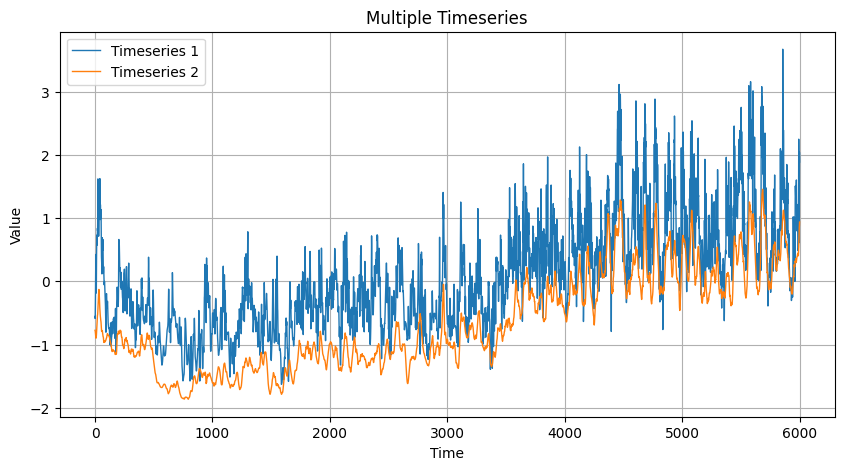

In [130]:
v_x_pdm_test = pdm_approximated_velocity(
    former_point=phi_y_1_test,
    latter_point=phi_y_2_test,
    delta_l=delta_y,
    B=B_z,
    )
y_pred_pdm_test = ss_y_true.transform(
    v_x_pdm_test,
    copy=False,
    )
mse_pdm = mean_squared_error(y_true_test, y_pred_pdm_test)
mses['PDM'] = mse_pdm
print(f"mse(pdm) = {mse_pdm}")
plot_timeseries(
    data_list=[
        y_true_test,
        y_pred_pdm_test,
        ],
    )

### Linear Scaled PDM (cPDM)

##### Prepare Data

In [131]:
phi_y_1 = extract_timeseries(
    data=fld_data,
    column_labels='F',
    y_coord=y_1_y,
    z_coord=y_1_z,
    )
phi_y_1_train, phi_y_1_test = train_test_split(
    phi_y_1,
    test_size=test_size,
    shuffle=False,
    )

phi_y_2 = extract_timeseries(
    data=fld_data,
    column_labels='F',
    y_coord=y_2_y,
    z_coord=y_2_z,
    )
phi_y_2_train, phi_y_2_test = train_test_split(
    phi_y_2,
    test_size=test_size,
    shuffle=False,
    )

##### Training

In [132]:
v_x_pdm_train = pdm_approximated_velocity(
    former_point=phi_y_1_train,
    latter_point=phi_y_2_train,
    delta_l=delta_y,
    B=B_z,
    )
y_pred_pdm_train = ss_y_true.transform(
    v_x_pdm_train,
    copy=False,
    )

model = LinearRegression(fit_intercept=False)
model.fit(
    X = v_x_pdm_train,
    y = y_true_train,
    )
c =  1 / model.coef_[0, 0]

##### Testing

mse(c-PDM) = 0.47102987674548935


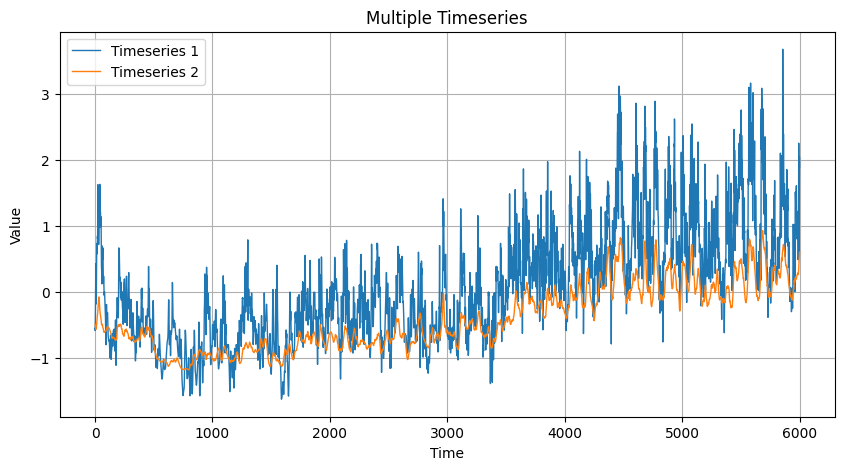

In [133]:
v_x_pdm_test = pdm_approximated_velocity(
    former_point=phi_y_1_test,
    latter_point=phi_y_2_test,
    delta_l=delta_y,
    B=B_z,
    )
y_pred_pdm_test = ss_y_true.transform(
    v_x_pdm_test,
    copy=False,
    )
y_pred_c_pdm_test = y_pred_pdm_test / c
mse_c_pdm = mean_squared_error(y_true_test, y_pred_c_pdm_test)
mses['c-PDM'] = mse_c_pdm
print(f"mse(c-PDM) = {mse_c_pdm}")
plot_timeseries(
    data_list=[
        y_true_test,
        y_pred_c_pdm_test,
        ],
    )

### Linear Regression on Feature: PDM

##### Prepare Data

In [134]:
phi_y_1 = extract_timeseries(
    data=fld_data,
    column_labels='F',
    y_coord=y_1_y,
    z_coord=y_1_z,
    )
phi_y_1_train, phi_y_1_test = train_test_split(
    phi_y_1,
    test_size=test_size,
    shuffle=False,
    )

phi_y_2 = extract_timeseries(
    data=fld_data,
    column_labels='F',
    y_coord=y_2_y,
    z_coord=y_2_z,
    )
phi_y_2_train, phi_y_2_test = train_test_split(
    phi_y_2,
    test_size=test_size,
    shuffle=False,
    )

##### Training

In [135]:
v_x_pdm_train = pdm_approximated_velocity(
    former_point=phi_y_1_train,
    latter_point=phi_y_2_train,
    delta_l=delta_y,
    B=B_z,
    )
v_x_pdm_train = ss_y_true.transform(
    v_x_pdm_train,
    copy=False,
    )

model = LinearRegression()
model.fit(
    X = v_x_pdm_train,
    y = y_true_train,
    );

##### Testing

mse(LR-PDM) = 0.2666241802847805


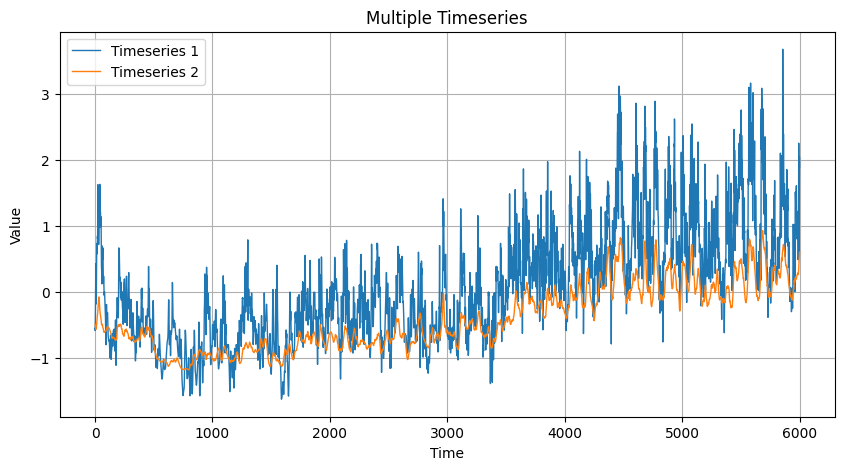

In [ ]:
v_x_pdm_test = pdm_approximated_velocity(
    former_point=phi_y_1_test,
    latter_point=phi_y_2_test,
    delta_l=delta_y,
    B=B_z,
    )
v_x_pdm_test = ss_y_true.transform(
    v_x_pdm_test,
    copy=False,
    )
y_pred_lr_pdm_test = model.predict(v_x_pdm_test)
mse_lr_pdm = mean_squared_error(y_true_test, y_pred_lr_pdm_test)
mses['LR-PDM'] = mse_lr_pdm
print(f"mse(LR-PDM) = {mse_lr_pdm}")
plot_timeseries(
    data_list=[
        y_true_test,
        y_pred_c_pdm_test,
        ],
    )

### Comparison

In [137]:
mses

{'General Benchmark': 0.010206003487330495,
 'PDM Benchmark': 0.04156472236966485,
 'PDM': 0.6850771111809714,
 'c-PDM': 0.47102987674548935,
 'LR-PDM': 0.2666241802847805}